In [2]:
import os
import pandas as pd
import seaborn as sns
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Data overview

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train_df["family_size"]=train_df["SibSp"]+train_df["Parch"]+ 1
test_df["family_size"]=train_df["SibSp"]+train_df["Parch"]+ 1
train_df.groupby(['family_size'], as_index=False) ['Survived'].agg(["count","mean"])

,family_size,count,mean
0,1,537,0.303538
1,2,161,0.552795
2,3,102,0.578431
3,4,29,0.724138
4,5,15,0.200000
5,6,22,0.136364
6,7,12,0.333333
7,8,6,0.000000
8,11,7,0.000000


In [5]:
train_df["fam_type"]=pd.cut(train_df.family_size, [0,1,4,7,11], labels=['solo','small','medium','big'])
test_df["fam_type"]=pd.cut(test_df.family_size, [0,1,4,7,11], labels=['solo','small','medium','big'])
train_df.groupby(['fam_type'], as_index=False ) ['Survived'].agg(["count","mean"])

C:\Users\HP\AppData\Local\Temp\ipykernel_18328\26761691.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['fam_type'], as_index=False ) ['Survived'].agg(["count","mean"])


,fam_type,count,mean
0,solo,537,0.303538
1,small,292,0.578767
2,medium,49,0.204082
3,big,13,0.000000


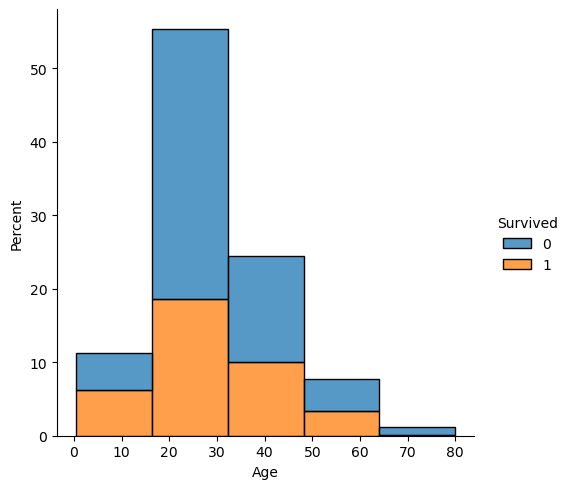

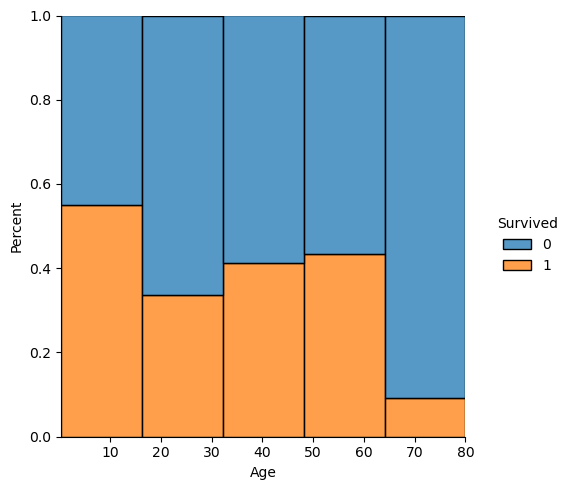

In [6]:
train_df["Age"]= train_df.groupby(["Sex",'Pclass'])["Age"].transform(lambda x:x.fillna(x.median()))
test_df["Age"]= test_df.groupby(["Sex",'Pclass'])["Age"].transform(lambda x:x.fillna(x.median()))

sns.displot(train_df , x='Age',hue='Survived',binwidth=17, height=5,multiple='stack',stat='percent')
sns.displot(train_df , x='Age',hue='Survived',binwidth=17, height=5,multiple='fill',stat='percent')

In [7]:
def encodeAge(train):
    train.loc[train_df['Age'] <= 17,'Age']=0
    train.loc[(train_df['Age'] >17) &  (train_df['Age'] <=32),'Age']=1
    train.loc[(train_df['Age'] >32) &  (train_df['Age'] <=48),'Age']=2
    train.loc[(train_df['Age'] >48) &  (train_df['Age'] <=64),'Age']=3
    train.loc[(train_df['Age'] >64) &  (train_df['Age'] <=80),'Age']=4
    
def encodeAge(test):
    train.loc[train_df['Age'] <= 17,'Age']=0
    train.loc[(train_df['Age'] >17) &  (train_df['Age'] <=32),'Age']=1
    train.loc[(train_df['Age'] >32) &  (train_df['Age'] <=48),'Age']=2
    train.loc[(train_df['Age'] >48) &  (train_df['Age'] <=64),'Age']=3
    train.loc[(train_df['Age'] >64) &  (train_df['Age'] <=80),'Age']=4

In [8]:
train_df.groupby(['Age'],as_index=False)['Survived'].mean()

,Age,Survived
0,0.42,1.0
1,0.67,1.0
2,0.75,1.0
3,0.83,1.0
4,0.92,1.0
...,...,...
84,70.00,0.0
85,70.50,0.0
86,71.00,0.0
87,74.00,0.0


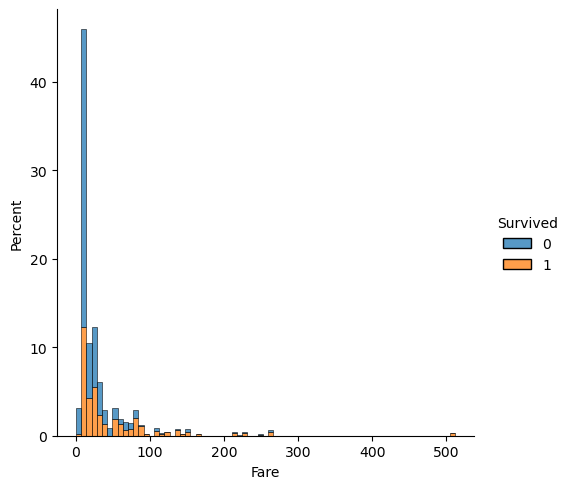

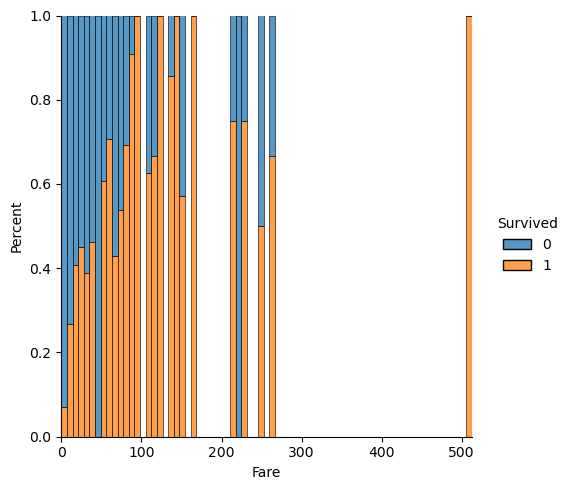

In [9]:
sns.displot(train_df , x='Fare',hue='Survived',binwidth=7, height=5,multiple='stack',stat='percent')
sns.displot(train_df , x='Fare',hue='Survived',binwidth=7, height=5,multiple='fill',stat='percent')

In [10]:
def encodeFare(train):
    train.loc[train_df['Fare'] <=7, 'Fare']=0
    train.loc[(train_df['Fare'] >7)&(train_df['Fare'] <= 14),'Fare']=1
    train.loc[(train_df['Fare'] >14)&(train_df['Fare'] <= 42),'Fare']=2
    train.loc[(train_df['Fare'] >42)&(train_df['Fare'] <= 512.329),'Fare']=3

def encodeFare(test):
    train.loc[train_df['Fare'] <=7, 'Fare']=0
    train.loc[(train_df['Fare'] >7)&(train_df['Fare'] <= 14),'Fare']=1
    train.loc[(train_df['Fare'] >14)&(train_df['Fare'] <= 42),'Fare']=2
    train.loc[(train_df['Fare'] >42)&(train_df['Fare'] <= 512.329),'Fare']=3

In [11]:
train_df.groupby(['Fare'],as_index=False)['Survived'].agg(["count","mean"])

,Fare,count,mean
0,0.0000,15,0.066667
1,4.0125,1,0.000000
2,5.0000,1,0.000000
3,6.2375,1,0.000000
4,6.4375,1,0.000000
...,...,...,...
243,227.5250,4,0.750000
244,247.5208,2,0.500000
245,262.3750,2,1.000000
246,263.0000,4,0.500000


In [12]:
train_df["Name"]

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [13]:
train_df["title"]=train_df['Name'].str.split(pat=",",expand=True)[1].str.split(pat=".",expand=True)[0].apply(lambda x: x.strip())
test_df["title"]=train_df['Name'].str.split(pat=",",expand=True)[1].str.split(pat=".",expand=True)[0].apply(lambda x: x.strip())

In [14]:
train_df.groupby(['title'],as_index=False)['Survived'].agg(["count","mean"])

,title,count,mean
0,Capt,1,0.000000
1,Col,2,0.500000
2,Don,1,0.000000
3,Dr,7,0.428571
4,Jonkheer,1,0.000000
5,Lady,1,1.000000
6,Major,2,0.500000
7,Master,40,0.575000
8,Miss,182,0.697802
9,Mlle,2,1.000000


In [15]:
train_df["title"]=train_df['title'].replace(['Capt','Col','Major','Rev','Dr'],'Officer')
train_df["title"]=train_df['title'].replace(['Mrs','Mme'],'Mrs')
train_df["title"]=train_df['title'].replace(['Miss','Ms','Mlle'],'Miss')
train_df["title"]=train_df['title'].replace(['Master'],'Master')
train_df["title"]=train_df['title'].replace(['Lady','the Countess','Sir','Jonkheer','Don'],'VIP')
train_df["title"]=train_df['title'].replace(['Mr'],'Mr')


test_df["title"]=train_df['title'].replace(['Capt','Call','Major','Rev','Dr'],'Officer')
test_df["title"]=train_df['title'].replace(['Mrs','Mme'],'Mrs')
test_df["title"]=train_df['title'].replace(['Miss','Ms','Mlle'],'Miss')
test_df["title"]=train_df['title'].replace(['Master'],'Master')
test_df["title"]=train_df['title'].replace(['Lady','the countess','Sir','Jonkheer','Don'],'VIP')
test_df["title"]=train_df['title'].replace(['Mr'],'Mr')


In [16]:
train_df.groupby(['title'],as_index=False)['Survived'].agg(["count","mean"])

,title,count,mean
0,Master,40,0.575000
1,Miss,185,0.702703
2,Mr,517,0.156673
3,Mrs,126,0.793651
4,Officer,18,0.277778
5,VIP,5,0.600000


In [17]:
train_df.Embarked=train_df.Embarked.fillna(train_df.Embarked.mode()[0])
train_df.Embarked=train_df.Embarked.fillna(train_df.Embarked.mode()[0])


In [18]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'family_size',
       'fam_type', 'title'],
      dtype='object')

In [19]:
train_df.drop(['PassengerId','Name','SibSp',
       'Parch', 'Ticket', 'family_size','Cabin'], inplace=True,axis=1)

test_df.drop(['PassengerId','Name','SibSp',
       'Parch', 'Ticket', 'family_size','Cabin'], inplace=True,axis=1)

In [20]:
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,fam_type,title
0,0,3,male,22.0,7.2500,S,small,Mr
1,1,1,female,38.0,71.2833,C,small,Mrs
2,1,3,female,26.0,7.9250,S,solo,Miss
3,1,1,female,35.0,53.1000,S,small,Mrs
4,0,3,male,35.0,8.0500,S,solo,Mr


In [21]:
from sklearn.preprocessing import LabelEncoder
train_df['Sex']=LabelEncoder().fit_transform(train_df["Sex"])
train_df['Embarked']=LabelEncoder().fit_transform(train_df["Embarked"])
train_df['fam_type']=LabelEncoder().fit_transform(train_df["fam_type"])
train_df['title']=LabelEncoder().fit_transform(train_df["title"])

test_df['Sex']=LabelEncoder().fit_transform(test_df["Sex"])
test_df['Embarked']=LabelEncoder().fit_transform(test_df["Embarked"])
test_df['fam_type']=LabelEncoder().fit_transform(test_df["fam_type"])
test_df['title']=LabelEncoder().fit_transform(test_df["title"])

In [22]:
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,fam_type,title
0,0,3,1,22.0,7.2500,2,2,2
1,1,1,0,38.0,71.2833,0,2,3
2,1,3,0,26.0,7.9250,2,3,1
3,1,1,0,35.0,53.1000,2,2,3
4,0,3,1,35.0,8.0500,2,3,2


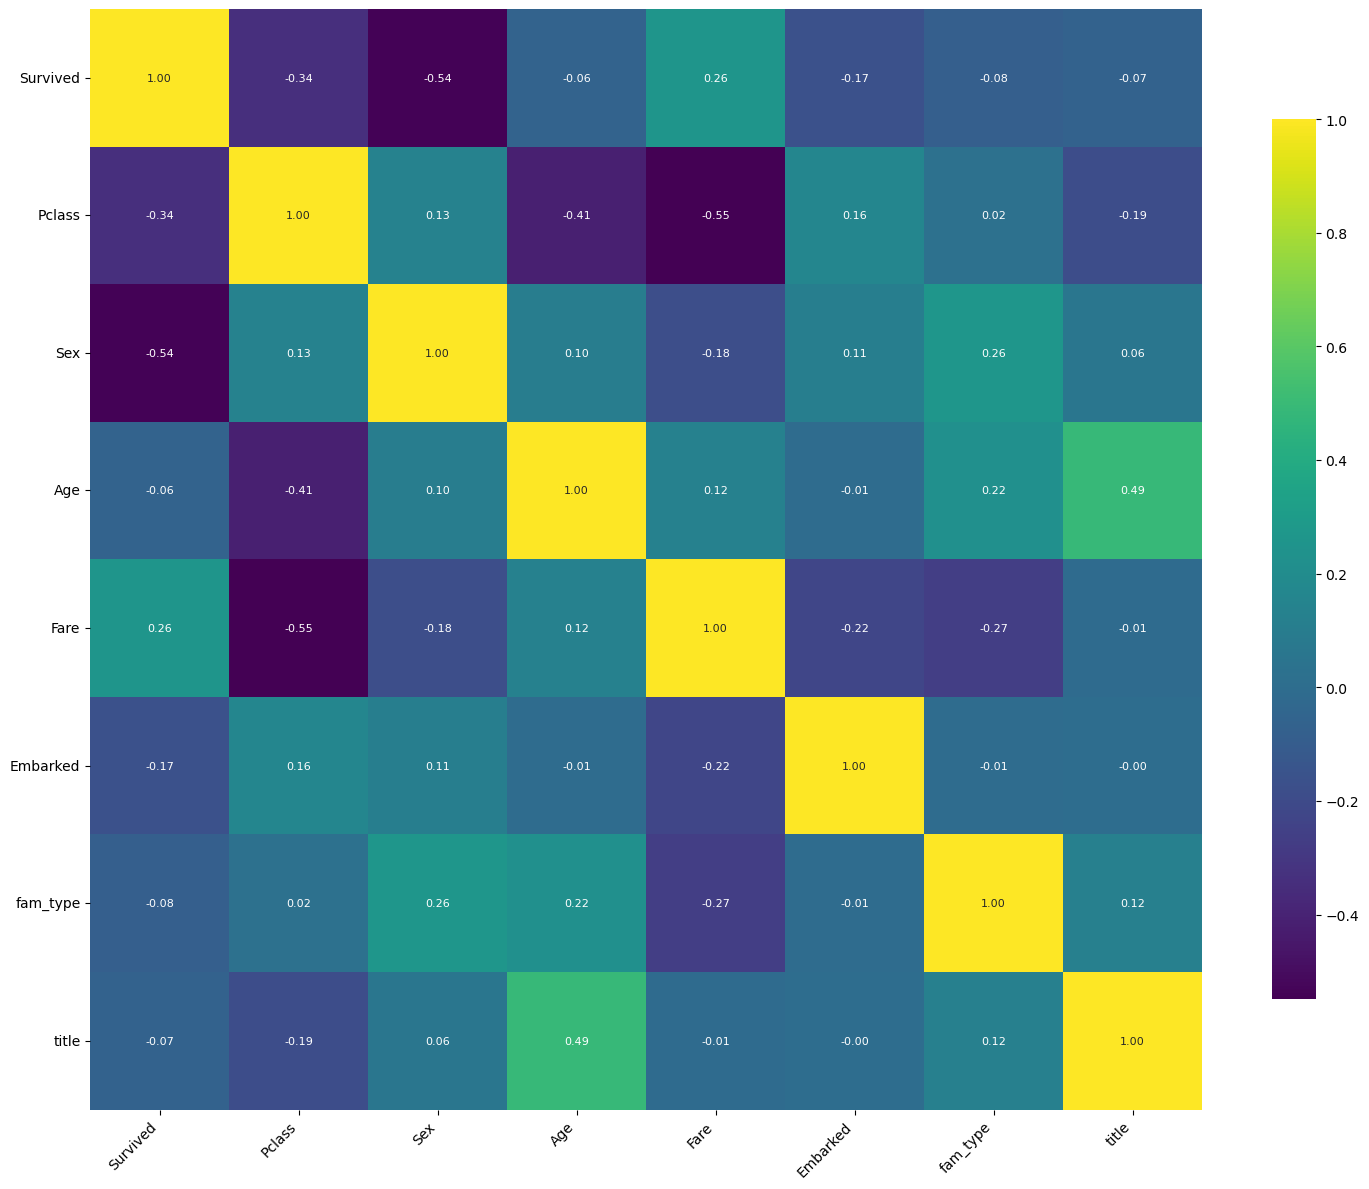

In [23]:
import matplotlib.pyplot as plt
correlation_matrix= train_df.corr(numeric_only=True)
plt.figure(figsize=(15,12))

heatmap= sns.heatmap(correlation_matrix,
                    annot=True,
                    cmap='viridis',
                    fmt='.2f',
                    annot_kws={"size":8},
                    cbar_kws={"shrink":0.8})

plt.xticks(rotation=45, ha ='right' , fontsize=10)
plt.yticks(rotation=0,fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
train_df=train_df.loc[:,['Survived','Pclass','Sex','Age','Fare','Embarked','fam_type','title']]
test_df=train_df.loc[:,['Pclass','Sex','Age','Fare','Embarked','fam_type','title']]

In [25]:
x=train_df.iloc[:,1:].values
y=train_df.iloc[:,0].values

from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=0)

In [26]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=10,n_estimators=200)
rf_model = rfc.fit(x_train , y_train)
y_pred= rf_model.predict(x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       110
           1       0.86      0.71      0.78        69

    accuracy                           0.84       179
   macro avg       0.85      0.82      0.83       179
weighted avg       0.85      0.84      0.84       179



In [27]:
y_pred= rf_model.predict(test_df)
test_data=pd.read_csv("test.csv")
a=test_data.iloc[:,0].values
dict={'PassengerId':a,'Survived': y_pred}

df1=pd.DataFrame(dict)
df1.to_csv('Titanic.csv',index=False)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: All arrays must be of the same length

In [ ]:
import pickle
file=open('Titanic prediction.pkl','wb')
pickle.dump(rf_model,file)